In [48]:
from pathlib import Path
from time import perf_counter
from datetime import datetime
from pathlib import Path
import json

from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))
import pandas as pd

from src import experiment_tracking
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

In [49]:
class_weight_value = None
c_value =  1.0
solver_value = "saga"
max_iter_value = 500
threshold_value = 0.50


nome_experimento = "logistica_sem_class_weight_c1_threshold_050"
observacoes_experimento =  "Segunda baseline de machine learning. Sem peso nas classes minoritárias"


In [50]:
df = pd.read_csv("../raw/fraudTrain.csv", parse_dates = ["trans_date_trans_time", "dob"], dtype = {"cc_num": "string", "trans_num": "string", "zip": "string"})

In [51]:
# Removendo a coluna de índice
colunas_sem_nome = [coluna for coluna in df.columns if coluna.startswith("Unnamed")]

df = df.drop(columns=colunas_sem_nome)

In [52]:
# Ordenando de maneira cronológica
df = (df.sort_values("trans_date_trans_time").reset_index(drop = True))

print(f"Linhas: {len(df):,}")
print(f"Colunas: {df.shape[1]}")
print(f"Início: {df['trans_date_trans_time'].min()}")
print(f"Fim: {df['trans_date_trans_time'].max()}")

Linhas: 1,296,675
Colunas: 22
Início: 2019-01-01 00:00:18
Fim: 2020-06-21 12:13:37


In [53]:
def calcular_distancia_km(
        lat_cliente: pd.Series,
        lon_cliente: pd.Series,
        lat_estabelecimento: pd.Series,
        lon_estabelecimento: pd.Series
) -> np.ndarray:
    """
    Calcula a distancia entre dois pontos geográficos utilizando a fórmula de Haversine.
    """

    raio_terra_km = 6371.0088

    lat1 = np.radians(lat_cliente.to_numpy())
    lon1 = np.radians(lon_cliente.to_numpy())
    lat2 = np.radians(lat_estabelecimento.to_numpy())
    lon2 = np.radians(lon_estabelecimento.to_numpy())

    delta_lat = lat2 - lat1
    delta_lon  = lon2 - lon1

    a = (np.sin(delta_lat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(delta_lon / 2) ** 2 )

    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return raio_terra_km * c

In [54]:
def criar_features(dados: pd.DataFrame) -> pd.DataFrame:
    """
    Cria as variáveis utilizadas pela Regressão Logística.
    
    Todas as variáveis são construídas usando apenas informações da própria transação.
    """

    features = pd.DataFrame(index = dados.index)

    data_transacao = dados["trans_date_trans_time"]
    data_nascimento = dados["dob"]

    # Valor da transação em escala logarítmica
    features["amt_log"] = np.log1p(dados["amt"])

    # População também apresenta assimetria
    features["city_pop_log"] = np.log1p(dados["city_pop"])

    # Idade exata na data da transação
    aniversario_ainda_nao_ocorreu = (data_transacao.dt.month < data_nascimento.dt.month) | ((data_transacao.dt.month == data_nascimento.dt.month) & (data_transacao.dt.day < data_nascimento.dt.day))

    features["idade"] = (
        data_transacao.dt.year - data_nascimento.dt.year - aniversario_ainda_nao_ocorreu.astype(int)
    )

    # Distância aproximada entre cliente e estabelecimento
    features["distancia_km"] = calcular_distancia_km(
        dados["lat"],
        dados["long"],
        dados["merch_lat"],
        dados["merch_long"]
    )

    # Variáveis temporais cíclicas
    hora = data_transacao.dt.hour

    features["hora_sin"] = np.sin(
        2 * np.pi * hora / 24
    )

    features["hora_cos"] = np.cos(
        2 * np.pi * hora / 24
    )

    dia_semana = data_transacao.dt.dayofweek

    features["dia_semana_sin"] = np.sin(
        2 * np.pi * dia_semana / 7
    )
    
    features["dia_semana_cos"] = np.cos(
        2 * np.pi * dia_semana / 7
    )

    features["fim_de_semana"] = (
        dia_semana >= 5
    ).astype(int)

    # variáveis categóricas
    features["category"] = dados["category"].astype("string")
    features["gender"] = dados["gender"].astype("string")
    features["state"] = dados["state"].astype("string")

    return features

In [55]:
# Separação temporal
# 70% dos dados mais antigos -> treino
# 15% seguinte -> validação
# 15% mais recente -> teste

limite_treino = int(len(df) * 0.7)
limite_validacao = int(len(df) * 0.85)

df_treino = df.iloc[:limite_treino].copy()

df_validacao = df.iloc[limite_treino:limite_validacao].copy()

df_teste = df.iloc[limite_validacao:].copy()

In [56]:
# criando as features
X_treino = criar_features(df_treino)
X_validacao = criar_features(df_validacao)
X_teste = criar_features(df_teste)

y_treino = df_treino["is_fraud"].astype(int)
y_validacao = df_validacao["is_fraud"].astype(int)
y_teste = df_teste["is_fraud"].astype(int)

In [57]:
def resumo_particao(nome: str, dados: pd.DataFrame, target: pd.Series) -> dict:
    return {
        "particao": nome,
        "inicio": dados["trans_date_trans_time"].min(), 
        "fim": dados["trans_date_trans_time"].max(),
        "transacoes": len(dados),
        "fraudes": int(target.sum()),
        "taxa_fraude_percentual": target.mean() * 100
    }

resumo_particoes = pd.DataFrame([
    resumo_particao("Treino", df_treino, y_treino),
    resumo_particao("Validação", df_validacao, y_validacao),
    resumo_particao("Teste", df_teste, y_teste)
])

In [58]:
resumo_particoes

,particao,inicio,fim,transacoes,fraudes,taxa_fraude_percentual
0,Treino,2019-01-01 00:00:18,2019-12-28 17:18:24,907672,5121,0.564191
1,Validação,2019-12-28 17:18:38,2020-04-03 17:53:52,194501,1252,0.643698
2,Teste,2020-04-03 17:54:44,2020-06-21 12:13:37,194502,1133,0.582513


In [59]:
experimento = experiment_tracking.iniciar_experimento(
    nome_experimento
)

parametros_experimento = {
    "modelo": "LogisticRegression",
    "class_weight": class_weight_value,
    "C": c_value,
    "solver": solver_value,
    "max_iter": max_iter_value,
    "threshold": threshold_value,
    "random_state": 42,
    "split": "temporal_70_15_15",
    "features": [
        "amt_log",
        "city_pop_log",
        "idade",
        "distancia_km",
        "hora_sin",
        "hora_cos",
        "dia_semana_sin",
        "dia_semana_cos",
        "fim_de_semana",
        "category",
        "gender",
        "state"
    ]
}

experiment_tracking.salvar_json(
    parametros_experimento,
    experimento["pasta_run"] / "parametros.json"
)

Experimento criado: 20260727_001442__logistica_sem_class_weight_c1_threshold_050
Pasta: /Users/lucassantos/Documents/ccard_fraud_ml/outputs/experiments/20260727_001442__logistica_sem_class_weight_c1_threshold_050


In [60]:
# variaveis que serão utilizadas

variaveis_numericas = [
    "amt_log",
    "city_pop_log",
    "idade",
    "distancia_km",
    "hora_sin",
    "hora_cos",
    "dia_semana_sin",
    "dia_semana_cos",
    "fim_de_semana"
]

variaveis_categoricas = [
   "category",
   "gender",
   "state"
]

In [61]:
# Tratando variaveis númericas
pipeline_numericas = Pipeline(
    steps = [
        (
            "preencher_nulos",
            SimpleImputer(strategy = "median")
        ),
        (
            "padronizar",
            StandardScaler()
        )
    ]
)

In [62]:
# one hot encoder serve para transformar todas as variáveis categóricas em binários
# criando o one hot encoder: 
try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown = "ignore",
        sparse_output = False
    )
except TypeError:
    one_hot_encoder = OneHotEncoder(
        handle_unknown = "ignore",
        sparse = False
    )

In [63]:
pipeline_categoricas = Pipeline(
    steps = [
        (
            "preencher_nulos",
            SimpleImputer(strategy = "most_frequent")
        ),
        (
            "one_hot",
            one_hot_encoder
        )
    ]
)

In [64]:
preprocessamento = ColumnTransformer(
    transformers=[
        (
            "numericas",
            pipeline_numericas,
            variaveis_numericas
        ),
        (
            "categoricas",
            pipeline_categoricas,
            variaveis_categoricas
        )
    ]
)

In [65]:
preprocessamento

ColumnTransformer(transformers=[('numericas',
                                 Pipeline(steps=[('preencher_nulos',
                                                  SimpleImputer(strategy='median')),
                                                 ('padronizar',
                                                  StandardScaler())]),
                                 ['amt_log', 'city_pop_log', 'idade',
                                  'distancia_km', 'hora_sin', 'hora_cos',
                                  'dia_semana_sin', 'dia_semana_cos',
                                  'fim_de_semana']),
                                ('categoricas',
                                 Pipeline(steps=[('preencher_nulos',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('one_hot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['category', 'gender', 'state'])])

In [66]:
regressao_logistica = LogisticRegression(
    solver = solver_value,
    class_weight = class_weight_value,
    C = c_value,
    max_iter = max_iter_value,
    random_state = 42
)

In [67]:
modelo = Pipeline(
    steps=[
        (
            "preprocessamento",
            preprocessamento
        ),
        (
            "classificador",
            regressao_logistica
        )
    ]
)

modelo

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('numericas',
                                                  Pipeline(steps=[('preencher_nulos',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('padronizar',
                                                                   StandardScaler())]),
                                                  ['amt_log', 'city_pop_log',
                                                   'idade', 'distancia_km',
                                                   'hora_sin', 'hora_cos',
                                                   'dia_semana_sin',
                                                   'dia_semana_cos',
                                                   'fim_de_semana']),
                                                 ('categoricas',
                                                  Pipeline(steps=[('preencher_nulos',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one_hot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['category', 'gender',
                                                   'state'])])),
                ('classificador',
                 LogisticRegression(max_iter=500, random_state=42,
                                    solver='saga'))])

In [68]:
X_treino

,amt_log,city_pop_log,idade,distancia_km,hora_sin,hora_cos,dia_semana_sin,dia_semana_cos,fim_de_semana,category,gender,state
0,1.786747,8.159375,30,78.597677,0.000000,1.000000,0.781831,0.623490,0,misc_net,F,NC
1,4.684259,5.010635,40,30.212217,0.000000,1.000000,0.781831,0.623490,0,grocery_pos,F,WA
2,5.398660,8.332068,56,108.206232,0.000000,1.000000,0.781831,0.623490,0,entertainment,M,ID
3,3.828641,7.570443,51,95.673363,0.000000,1.000000,0.781831,0.623490,0,gas_transport,M,MT
4,3.760269,4.605170,32,77.556851,0.000000,1.000000,0.781831,0.623490,0,misc_pos,M,VA
...,...,...,...,...,...,...,...,...,...,...,...,...
907667,4.215972,10.664714,37,82.676809,-0.965926,-0.258819,-0.974928,-0.222521,1,home,F,OR
907668,4.189655,11.662689,36,127.608274,-0.965926,-0.258819,-0.974928,-0.222521,1,health_fitness,F,VA
907669,1.961502,7.218177,79,93.708199,-0.965926,-0.258819,-0.974928,-0.222521,1,entertainment,F,VA
907670,3.476614,5.921578,24,126.410788,-0.965926,-0.258819,-0.974928,-0.222521,1,entertainment,F,MI


In [69]:
inicio_treinamento = perf_counter()

modelo.fit(
    X_treino,
    y_treino
)

tempo_treinamento = (
    perf_counter()
    - inicio_treinamento
)

print(
    f"Tempo de treinamento: "
    f"{tempo_treinamento:.2f} segundos"
)

Tempo de treinamento: 128.67 segundos


In [70]:
numero_iteracoes = (
    modelo
    .named_steps["classificador"]
    .n_iter_[0]
)

print(f"Número de iterações: {numero_iteracoes}")

Número de iterações: 200


In [71]:
scores_validacao = modelo.predict_proba(
    X_validacao
)[:, 1]

In [72]:
pd.Series(scores_validacao).describe(
    percentiles=[
        0.50,
        0.90,
        0.95,
        0.99,
        0.999
    ]
)

count    1.945010e+05
mean     5.765369e-03
std      2.975250e-02
min      5.169180e-08
50%      4.672589e-04
90%      1.025822e-02
95%      2.063779e-02
99%      8.135720e-02
99.9%    4.987976e-01
max      8.981744e-01
dtype: float64

In [73]:
threshold_inicial = 0.50

previsoes_validacao = (
    scores_validacao >= threshold_inicial
).astype(int)

In [74]:
def avaliar_modelo(
    y_real: pd.Series,
    scores: np.ndarray,
    threshold: float
) -> pd.DataFrame:
    previsoes = (
        scores >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_real,
        previsoes
    ).ravel()

    metricas = {
        "threshold": threshold,
        "average_precision": average_precision_score(
            y_real,
            scores
        ),
        "roc_auc": roc_auc_score(
            y_real,
            scores
        ),
        "accuracy": accuracy_score(
            y_real,
            previsoes
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_real,
            previsoes
        ),
        "precision_fraude": precision_score(
            y_real,
            previsoes,
            zero_division=0
        ),
        "recall_fraude": recall_score(
            y_real,
            previsoes,
            zero_division=0
        ),
        "f1_fraude": f1_score(
            y_real,
            previsoes,
            zero_division=0
        ),
        "verdadeiros_negativos": tn,
        "falsos_positivos": fp,
        "falsos_negativos": fn,
        "verdadeiros_positivos": tp,
        "percentual_alertado": previsoes.mean() * 100
    }

    return pd.DataFrame(
        [metricas]
    )

In [75]:
resultado_threshold_05 = avaliar_modelo(
    y_validacao,
    scores_validacao,
    threshold=0.50
)


print(resultado_threshold_05.T)

# ============================================================================
# RESUMO DAS MÉTRICAS DE CLASSIFICAÇÃO
#
# threshold:
# Ponto de corte usado para converter o score em classe.
# Score >= threshold é classificado como fraude.
#
# average_precision:
# Resume a curva Precision-Recall em diferentes thresholds.
# Quanto maior, melhor o modelo prioriza as fraudes no ranking de risco.
#
# roc_auc:
# Mede a capacidade geral de ordenar fraudes acima de transações legítimas.
# Varia de 0,5 (aleatório) a 1,0 (separação perfeita).
#
# accuracy:
# Percentual total de previsões corretas.
# Pode ser enganosa quando as classes são muito desbalanceadas.
#
# balanced_accuracy:
# Média do recall de cada classe, dando a mesma importância para
# transações legítimas e fraudulentas.
#
# precision_fraude:
# Entre todas as transações alertadas, qual proporção realmente era fraude.
#
# recall_fraude:
# Entre todas as fraudes existentes, qual proporção o modelo identificou.
#
# f1_fraude:
# Média harmônica entre Precision e Recall.
# Mede o equilíbrio entre encontrar fraudes e evitar falsos alertas.
#
# verdadeiros_negativos:
# Transações legítimas corretamente classificadas como legítimas.
#
# falsos_positivos:
# Transações legítimas classificadas incorretamente como fraude.
#
# falsos_negativos:
# Fraudes classificadas incorretamente como legítimas.
#
# verdadeiros_positivos:
# Fraudes corretamente identificadas pelo modelo.
#
# percentual_alertado:
# Percentual de todas as transações que o modelo encaminhou como suspeitas.
# Representa a carga operacional de alertas.
# ============================================================================

                                   0
threshold                   0.500000
average_precision           0.402176
roc_auc                     0.890698
accuracy                    0.993902
balanced_accuracy           0.551751
precision_fraude            0.670103
recall_fraude               0.103834
f1_fraude                   0.179806
verdadeiros_negativos  193185.000000
falsos_positivos           64.000000
falsos_negativos         1122.000000
verdadeiros_positivos     130.000000
percentual_alertado         0.099742


In [76]:
print(
    classification_report(
        y_validacao,
        previsoes_validacao,
        target_names=[
            "Legítima",
            "Fraude"
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Legítima     0.9942    0.9997    0.9969    193249
      Fraude     0.6701    0.1038    0.1798      1252

    accuracy                         0.9939    194501
   macro avg     0.8322    0.5518    0.5884    194501
weighted avg     0.9921    0.9939    0.9917    194501



Figura salva: ../outputs/experiments/20260727_001442__logistica_sem_class_weight_c1_threshold_050/plots/matriz_confusao.png


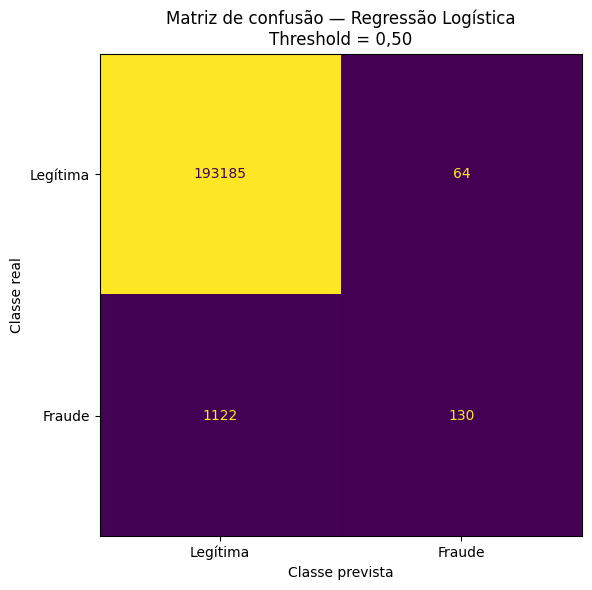

In [77]:
matriz = confusion_matrix(
    y_validacao,
    previsoes_validacao
)

fig, ax = plt.subplots(figsize=(7, 6))

visualizacao = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=[
        "Legítima",
        "Fraude"
    ]
)

visualizacao.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

plt.title(
    "Matriz de confusão — Regressão Logística\n"
    "Threshold = 0,50"
)

plt.xlabel("Classe prevista")
plt.ylabel("Classe real")

plt.tight_layout()

experiment_tracking.salvar_figura(
    fig=fig,
    pasta_plots=experimento["pasta_plots"],
    nome_arquivo="matriz_confusao"
)
plt.show()

Figura salva: ../outputs/experiments/20260727_001442__logistica_sem_class_weight_c1_threshold_050/plots/curva_precision_recall.png


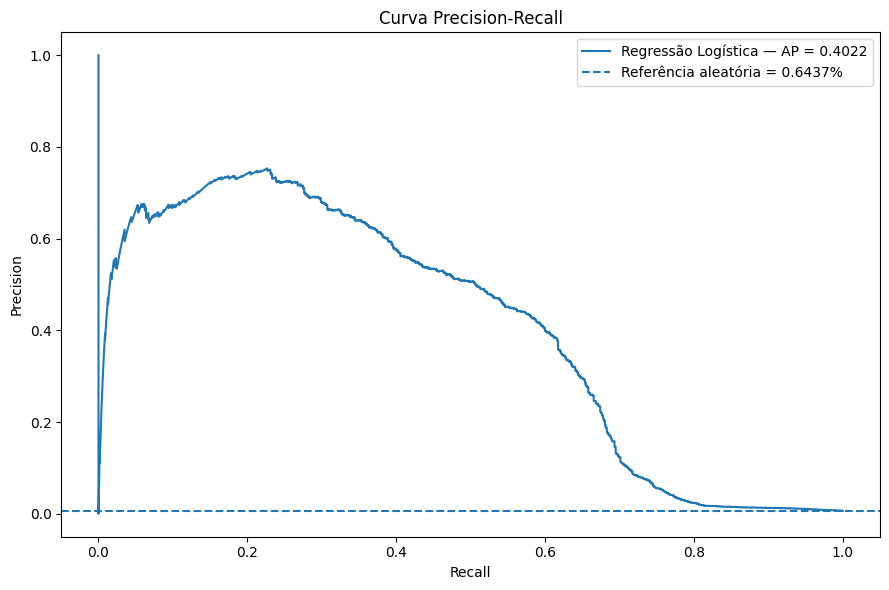

In [78]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

precision, recall, thresholds_pr = precision_recall_curve(
    y_validacao,
    scores_validacao
)

average_precision = average_precision_score(
    y_validacao,
    scores_validacao
)

prevalencia = y_validacao.mean()

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    recall,
    precision,
    label=f"Regressão Logística — AP = {average_precision:.4f}"
)

ax.axhline(
    prevalencia,
    linestyle="--",
    label=f"Referência aleatória = {prevalencia:.4%}"
)

ax.set_title("Curva Precision-Recall")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()

fig.tight_layout()

experiment_tracking.salvar_figura(
    fig,
    experimento["pasta_plots"],
    "curva_precision_recall"
)

plt.show()

In [79]:
dados_curva_pr = pd.DataFrame({
    "recall": recall,
    "precision": precision
})

dados_curva_pr.to_csv(
    experimento["pasta_dados_graficos"]
    / "curva_precision_recall.csv",
    index=False,
    encoding="utf-8-sig"
)

Figura salva: ../outputs/experiments/20260727_001442__logistica_sem_class_weight_c1_threshold_050/plots/curva_roc.png


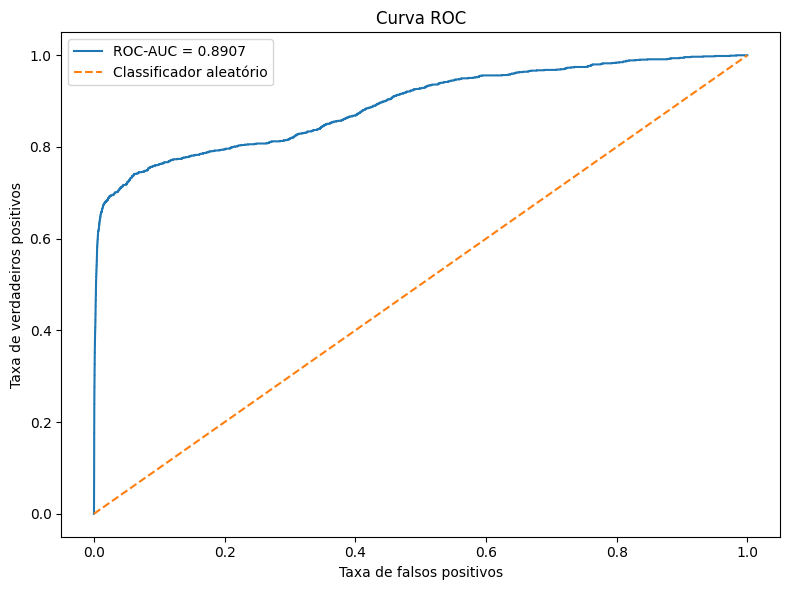

In [80]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds_roc = roc_curve(
    y_validacao,
    scores_validacao
)

roc_auc = roc_auc_score(
    y_validacao,
    scores_validacao
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificador aleatório"
)

ax.set_title("Curva ROC")
ax.set_xlabel("Taxa de falsos positivos")
ax.set_ylabel("Taxa de verdadeiros positivos")
ax.legend()

fig.tight_layout()

experiment_tracking.salvar_figura(
    fig,
    experimento["pasta_plots"],
    "curva_roc"
)

plt.show()

In [81]:
dados_curva_roc = pd.DataFrame({
    "fpr": fpr,
    "tpr": tpr,
    "threshold": thresholds_roc
})

dados_curva_roc.to_csv(
    experimento["pasta_dados_graficos"]
    / "curva_roc.csv",
    index=False,
    encoding="utf-8-sig"
)

Figura salva: ../outputs/experiments/20260727_001442__logistica_sem_class_weight_c1_threshold_050/plots/precision_recall_por_threshold.png


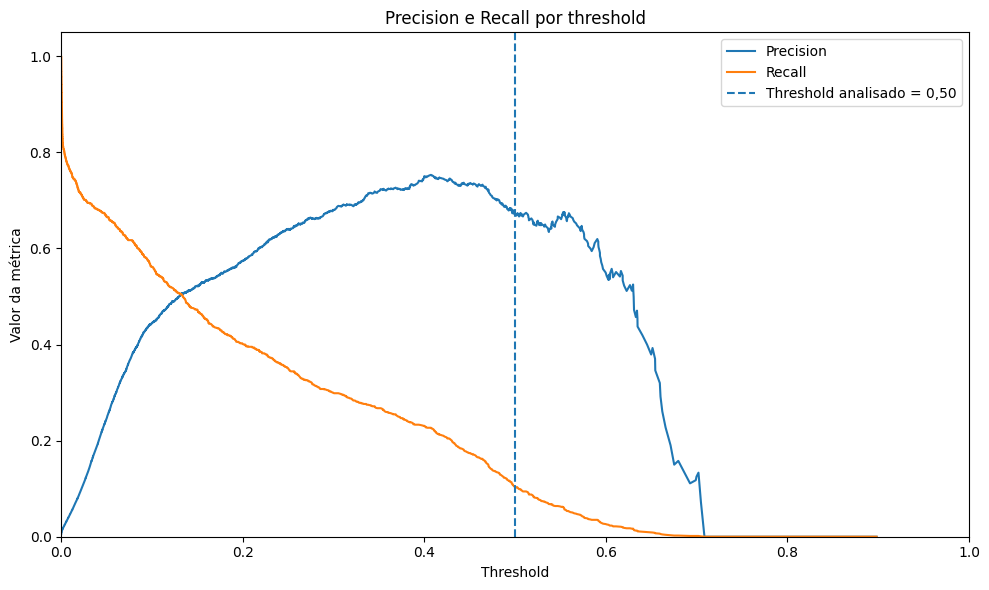

In [82]:
dados_thresholds = pd.DataFrame({
    "threshold": thresholds_pr,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    dados_thresholds["threshold"],
    dados_thresholds["precision"],
    label="Precision"
)

ax.plot(
    dados_thresholds["threshold"],
    dados_thresholds["recall"],
    label="Recall"
)

ax.axvline(
    0.50,
    linestyle="--",
    label="Threshold analisado = 0,50"
)

ax.set_title("Precision e Recall por threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Valor da métrica")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend()

fig.tight_layout()

experiment_tracking.salvar_figura(
    fig,
    experimento["pasta_plots"],
    "precision_recall_por_threshold"
)

plt.show()

dados_thresholds.to_csv(
    experimento["pasta_dados_graficos"]
    / "precision_recall_por_threshold.csv",
    index=False,
    encoding="utf-8-sig"
)

Figura salva: ../outputs/experiments/20260727_001442__logistica_sem_class_weight_c1_threshold_050/plots/distribuicao_scores_por_classe.png


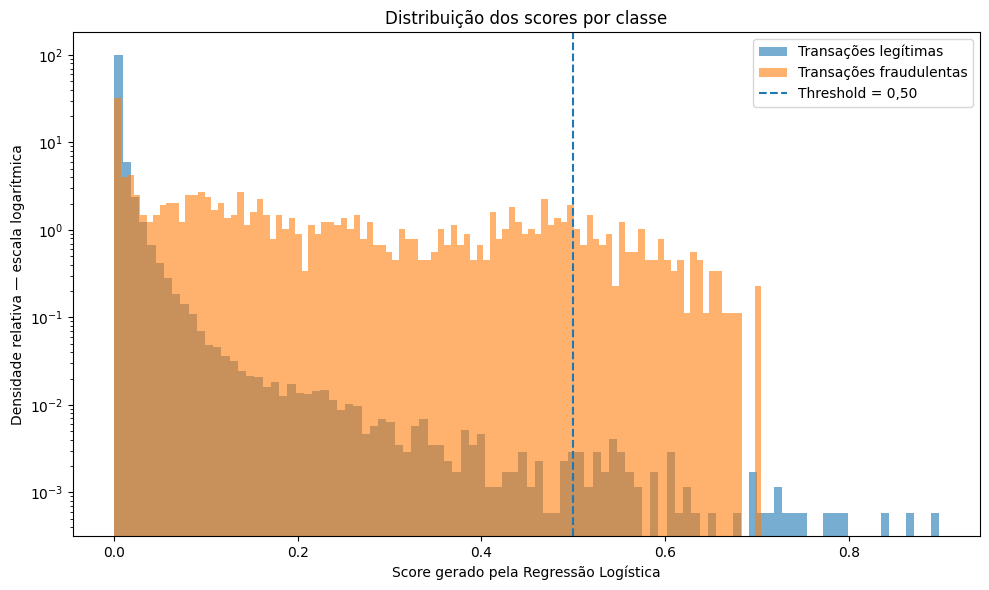

In [83]:
scores_legitimas = scores_validacao[
    y_validacao.to_numpy() == 0
]

scores_fraudes = scores_validacao[
    y_validacao.to_numpy() == 1
]

plt.figure(figsize=(10, 6))

plt.hist(
    scores_legitimas,
    bins=100,
    density=True,
    alpha=0.6,
    label="Transações legítimas"
)

plt.hist(
    scores_fraudes,
    bins=100,
    density=True,
    alpha=0.6,
    label="Transações fraudulentas"
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Threshold = 0,50"
)

plt.yscale("log")

plt.title("Distribuição dos scores por classe")
plt.xlabel("Score gerado pela Regressão Logística")
plt.ylabel("Densidade relativa — escala logarítmica")
plt.legend()

experiment_tracking.salvar_figura(
    fig=fig,
    pasta_plots=experimento["pasta_plots"],
    nome_arquivo="distribuicao_scores_por_classe"
)

plt.tight_layout()
plt.show()

In [84]:
nomes_features = (
    modelo
    .named_steps["preprocessamento"]
    .get_feature_names_out()
)

coeficientes = (
    modelo
    .named_steps["classificador"]
    .coef_[0]
)

tabela_coeficientes = pd.DataFrame({
    "variavel": nomes_features,
    "coeficiente": coeficientes
})

tabela_coeficientes["variavel"] = (
    tabela_coeficientes["variavel"]
    .str.replace("numericas__", "", regex=False)
    .str.replace("categoricas__", "", regex=False)
)

tabela_coeficientes["coeficiente_absoluto"] = (
    tabela_coeficientes["coeficiente"].abs()
)

tabela_coeficientes = (
    tabela_coeficientes
    .sort_values(
        "coeficiente_absoluto",
        ascending=False
    )
)



tabela_coeficientes.head(20)

,variavel,coeficiente,coeficiente_absoluto
33,state_DE,3.684437,3.684437
0,amt_log,1.881838,1.881838
64,state_RI,1.785556,1.785556
22,category_travel,-1.708500,1.708500
5,hora_cos,1.365686,1.365686
71,state_VT,-1.178439,1.178439
13,category_grocery_pos,1.047223,1.047223
17,category_misc_net,0.935410,0.935410
11,category_gas_transport,0.892254,0.892254
20,category_shopping_net,0.845408,0.845408


In [85]:
maiores_positivos = (
    tabela_coeficientes
    .nlargest(12, "coeficiente")
)

maiores_negativos = (
    tabela_coeficientes
    .nsmallest(12, "coeficiente")
)

coeficientes_plot = pd.concat([
    maiores_negativos,
    maiores_positivos
]).sort_values("coeficiente")

Figura salva: ../outputs/experiments/20260727_001442__logistica_sem_class_weight_c1_threshold_050/plots/matriz_confusao.png


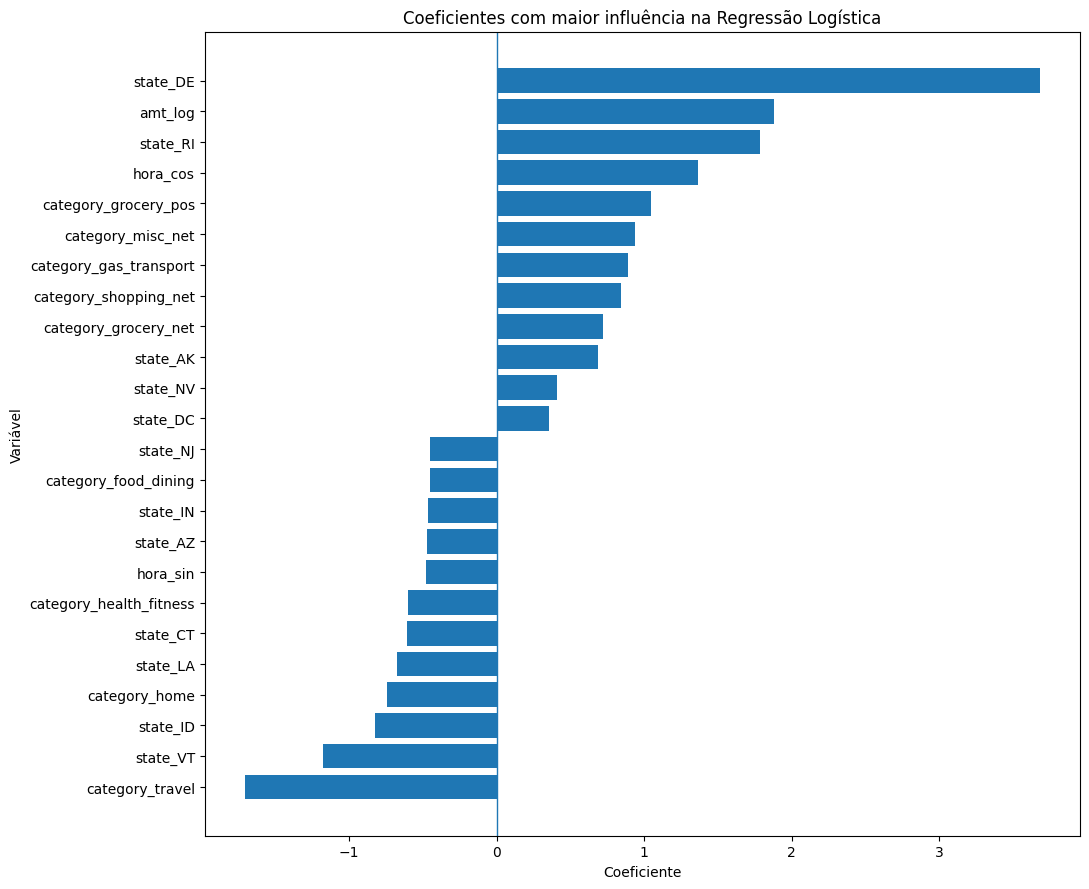

In [86]:
plt.figure(figsize=(11, 9))

plt.barh(
    coeficientes_plot["variavel"],
    coeficientes_plot["coeficiente"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.title(
    "Coeficientes com maior influência "
    "na Regressão Logística"
)

plt.xlabel("Coeficiente")
plt.ylabel("Variável")

experiment_tracking.salvar_figura(
    fig=fig,
    pasta_plots=experimento["pasta_plots"],
    nome_arquivo="matriz_confusao"
)

plt.tight_layout()
plt.show()

In [87]:

CAMINHO_RESULTADOS = Path(
    "../outputs/resultados_modelos.csv"
)


def salvar_resultado_experimento(
    resultado,
    nome_modelo: str,
    nome_experimento: str,
    parametros: dict ,
    conjunto_features: str = "",
    observacoes: str = "",
    tempo_treinamento_segundos: float = "",
    caminho: Path = CAMINHO_RESULTADOS
) -> pd.DataFrame:
    """
    Salva uma execução do modelo em um arquivo CSV.

    Cada linha do arquivo representa um experimento.
    """

    caminho.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    # Aceita tanto um DataFrame de uma linha quanto um dicionário.
    if isinstance(resultado, pd.DataFrame):
        if len(resultado) != 1:
            raise ValueError(
                "O DataFrame de resultado deve possuir exatamente uma linha."
            )

        registro = resultado.iloc[0].to_dict()

    elif isinstance(resultado, dict):
        registro = resultado.copy()

    else:
        raise TypeError(
            "resultado deve ser um DataFrame de uma linha ou um dicionário."
        )

    metadados = {
        "data_execucao": datetime.now().isoformat(
            timespec="seconds"
        ),
        "nome_experimento": nome_experimento,
        "nome_modelo": nome_modelo,
        "conjunto_features": conjunto_features,
        "parametros": json.dumps(
            parametros or {},
            ensure_ascii=False,
            sort_keys=True
        ),
        "tempo_treinamento_segundos": (
            tempo_treinamento_segundos
        ),
        "observacoes": observacoes
    }

    registro_completo = {
        **metadados,
        **registro
    }

    nova_linha = pd.DataFrame(
        [registro_completo]
    )

    arquivo_ja_existe = caminho.exists()

    nova_linha.to_csv(
        caminho,
        mode="a",
        header=not arquivo_ja_existe,
        index=False,
        encoding="utf-8-sig"
    )

    print(
        f"Experimento salvo em: {caminho.resolve()}"
    )

    return nova_linha

In [88]:
salvar_resultado_experimento(
    resultado=resultado_threshold_05,
    nome_modelo="Regressão Logística",
    nome_experimento=nome_experimento,
    parametros={
        "class_weight": class_weight_value,
        "C": c_value,
        "solver": solver_value,
        "max_iter": max_iter_value,
        "threshold": threshold_value
    },
    conjunto_features="features_basicas_v1",
    tempo_treinamento_segundos=tempo_treinamento,
    observacoes=(
     observacoes_experimento
    )
)

Experimento salvo em: /Users/lucassantos/Documents/ccard_fraud_ml/outputs/resultados_modelos.csv


,data_execucao,nome_experimento,nome_modelo,conjunto_features,parametros,tempo_treinamento_segundos,observacoes,threshold,average_precision,roc_auc,accuracy,balanced_accuracy,precision_fraude,recall_fraude,f1_fraude,verdadeiros_negativos,falsos_positivos,falsos_negativos,verdadeiros_positivos,percentual_alertado
0,2026-07-27T00:16:55,logistica_sem_class_weight_c1_threshold_050,Regressão Logística,features_basicas_v1,"{""C"": 1.0, ""class_weight"": null, ""max_iter"": 5...",128.666058,Segunda baseline de machine learning. Sem peso...,0.5,0.402176,0.890698,0.993902,0.551751,0.670103,0.103834,0.179806,193185.0,64.0,1122.0,130.0,0.099742
